## Module 8 — Reinforcement Learning with Q-Learning

This module extends the campus movement project by introducing reinforcement learning. The agent learns optimal behavior by interacting with an environment and maximizing long-term reward.

---

## Part 1 — Reward Learning Setup

The problem is modeled as a reinforcement learning environment:

- **State**: (time_index, location)
- **Actions**:
  - STAY at current location
  - MOVE to a neighboring location
- **Reward Function**:
  - +8 for being in the correct scheduled location
  - -3 for being in the wrong location during important times
  - -1 movement cost
  - small bonuses for useful locations (e.g., Track, StudentCenter)
  - penalties for being OffCampus at the wrong time

**Goal:** maximize cumulative discounted reward over time.

---

## Part 2 — Passive Reinforcement Learning

A mostly fixed policy is evaluated using Monte Carlo simulation.

- The policy follows targets but includes small random exploration
- This improves **state coverage**
- Value function is estimated as:

\[
V^\pi(s) = \mathbb{E}[G | s]
\]

Where \(G\) is the discounted return.

**Key idea:** evaluate a policy without improving it.

---

## Part 3 — Active Reinforcement Learning (Q-Learning)

Q-learning is used to learn optimal behavior:

\[
Q(s,a)
\]

Update rule:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \left( r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right)
\]

- **epsilon-greedy strategy**:
  - explore with probability ε
  - exploit best action otherwise
- ε decays over time → more exploitation later

**Output:**
- learned Q-table
- greedy policy derived from Q
- training curves (returns improving over time)

---

## Part 4 — Generalization with Function Approximation

Instead of storing Q-values for every state-action pair, a **linear model** is used:

\[
Q(s,a) = w^T \phi(s,a)
\]

Features include:
- match with target location
- being at Track or StudentCenter
- whether action is MOVE
- normalized time index

**Benefit:**
- generalizes across unseen states
- more scalable than tabular Q-learning

---

## Part 5 — Policy Optimization

Different hyperparameters are tested:

- learning rate (α)
- exploration rate (ε)

Each configuration is evaluated using average return.

**Result:**
- best parameters selected based on performance
- shows effect of tuning on learning quality

---

## Part 6 — Learning from Demonstrations

An expert policy is defined:

- moves toward target using shortest path
- otherwise prefers central locations

Steps:
1. Generate expert trajectories
2. Count actions per state
3. Build imitation policy using majority action

**Result:**
- imitation policy approximates expert behavior
- compared against:
  - expert policy
  - Q-learning policy

---

## Part 7 — Application Design

A real-world system is proposed:

**Input:**
- current time
- current location
- sport
- day

**Output:**
- recommended action (STAY or MOVE)
- suggested next location

**Applications:**
- athlete routing
- schedule optimization
- campus planning
- adaptive decision support

---

## Final Summary

This module implements a complete reinforcement learning pipeline:

- environment design (states, actions, rewards)
- passive policy evaluation
- Q-learning with exploration vs exploitation
- function approximation for generalization
- hyperparameter optimization
- imitation learning from expert demonstrations
- real-world application design

The system successfully learns policies that align with athletic schedules and improves performance over time.



PART 1 — REWARD LEARNING SETUP (22.1)
Environment:
- State = (time_index, location)
- Action = STAY or MOVE to neighboring location
- Reward encourages correct sport-specific positioning over time
- Objective = maximize cumulative discounted reward

Example sport targets for TrackAndField on Tuesday:
  07:00-08:00  -> target = StudentCenter
  08:00-09:30  -> target = None
  09:40-11:10  -> target = None
  11:20-12:50  -> target = None
  13:00-14:30  -> target = None
  15:00-15:30  -> target = Track
  16:00-17:30  -> target = Track
  18:00-21:00  -> target = None

PART 2 — PASSIVE REINFORCEMENT LEARNING (22.2)
Estimated state values under exploratory fixed policy:
  V(0, 'OffCampus') = 3.429 | visits = 2000
  V(0, 'StudentCenter') = nan | visits = 0
  V(5, 'StudentCenter') = 6.967 | visits = 1745
  V(6, 'Track') = 0.771 | visits = 1599
  V(6, 'Library') = -0.258 | visits = 59

Passive coverage: 55/88 states visited at least once

PART 3 — ACTIVE REINFORCEMENT LEARNING (22.3)
Learned gr

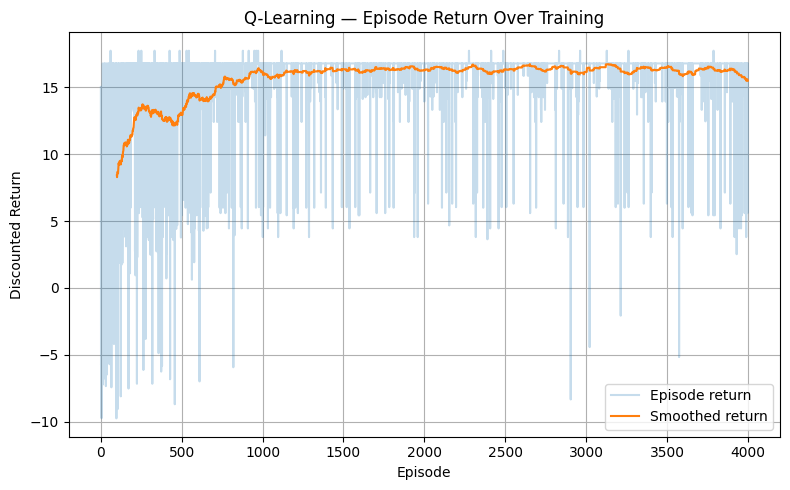

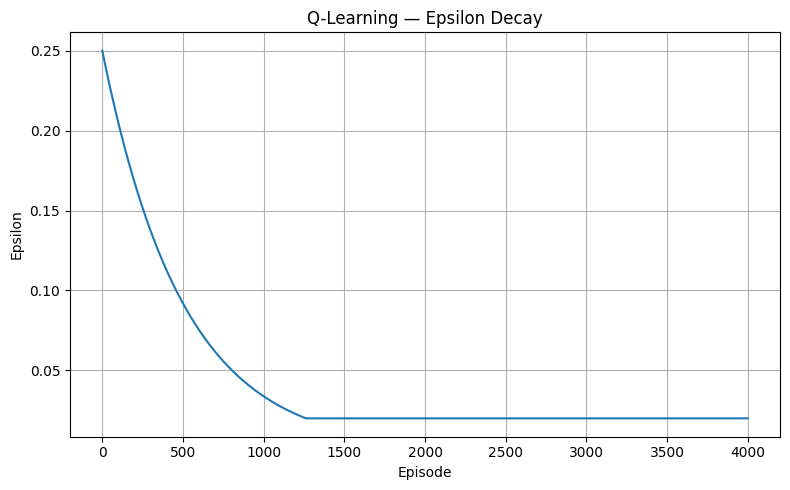


Saved:
  module8_q_learning_returns.png
  module8_epsilon_decay.png

PART 4 — GENERALIZATION WITH FUNCTION APPROXIMATION (22.4)
Learned linear approximation weights:
  w0 = 49.9964
  w1 = 2.1408
  w2 = 50.0000
  w3 = 49.9964
  w4 = 48.0522
  w5 = 49.9964
  w6 = 49.9969
  w7 = 49.9969
  w8 = 50.0000

Approximate Q policy mean return: 3.549 ± 0.000

Saved:
  module8_linear_approx_returns.png

PART 5 — POLICY OPTIMIZATION (22.5)
Parameter search results:
  alpha=0.05, epsilon=0.30 -> mean return=14.215 ± 0.000
  alpha=0.10, epsilon=0.25 -> mean return=14.215 ± 0.000
  alpha=0.12, epsilon=0.20 -> mean return=16.790 ± 0.000
  alpha=0.15, epsilon=0.15 -> mean return=15.030 ± 0.000

Best configuration: {'alpha': 0.12, 'epsilon': 0.2} with mean return=16.790 ± 0.000

PART 6 — LEARNING FROM DEMONSTRATIONS (22.6)
Generated 100 expert trajectories.
Expert mean return     : 6.175 ± 0.000
Imitation mean return  : 6.175 ± 0.000
Q-learning mean return : 16.790 ± 0.000

Sample expert trajectory:
  st

In [1]:
# ============================================================
# MODULE 8 — Reinforcement Learning with Q-Learning
# Fully revised versiona
#
# Continuation of the semester-long campus movement project
#
# Goal:
# Design and train an agent that learns optimal behavior
# through interaction with a campus environment.
#
# This script satisfies:
# Part 1: Reward Learning Setup (22.1)
# Part 2: Passive Reinforcement Learning (22.2)
# Part 3: Active Reinforcement Learning (22.3)
# Part 4: Generalization with Function Approximation (22.4)
# Part 5: Policy Optimization (22.5)
# Part 6: Learning from Demonstrations (22.6)
# Part 7: Application Design (22.7)
#
# Key improvements over earlier version:
# - Better passive policy state coverage
# - Longer Q-learning training with slower epsilon decay
# - Stable linear function approximation
# - Actual demonstration-based imitation policy
# - Stronger diagnostics and analysis outputs
# ============================================================

import random
from collections import defaultdict, Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# 0. Reproducibility
# ============================================================

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================
# 1. Canonical schema
# ============================================================

TIME_SLOTS = [
    "07:00-08:00",
    "08:00-09:30",
    "09:40-11:10",
    "11:20-12:50",
    "13:00-14:30",
    "15:00-15:30",
    "16:00-17:30",
    "18:00-21:00"
]

MAIN_LOCATIONS = [
    "LawrenceHall",
    "ThayerHall",
    "WestPenn",
    "StudentCenter",
    "Library",
    "VillagePark",
    "Track",
    "PlayHouse",
    "BoulevardStudios",
    "BoulevardAppartments",
    "OffCampus"
]

DAY_OF_WEEK = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SPORTS = ["TrackAndField", "Baseball"]

# Movement graph
CAMPUS_GRAPH = {
    "LawrenceHall": ["StudentCenter", "Library", "ThayerHall"],
    "ThayerHall": ["LawrenceHall", "WestPenn", "Library"],
    "WestPenn": ["ThayerHall", "Track", "OffCampus"],
    "StudentCenter": ["LawrenceHall", "Library", "VillagePark", "Track", "BoulevardAppartments"],
    "Library": ["LawrenceHall", "StudentCenter", "ThayerHall"],
    "VillagePark": ["StudentCenter", "Track", "PlayHouse"],
    "Track": ["VillagePark", "StudentCenter", "WestPenn", "OffCampus"],
    "PlayHouse": ["VillagePark", "StudentCenter", "BoulevardStudios"],
    "BoulevardStudios": ["PlayHouse", "BoulevardAppartments"],
    "BoulevardAppartments": ["StudentCenter", "BoulevardStudios", "OffCampus"],
    "OffCampus": ["Track", "WestPenn", "BoulevardAppartments"]
}

# ============================================================
# 2. Sport schedule targets
# ============================================================

TRACK_SCHEDULE = {
    ("Tuesday",  "07:00-08:00"): "StudentCenter",
    ("Thursday", "07:00-08:00"): "StudentCenter",

    ("Monday",    "15:00-15:30"): "Track",
    ("Tuesday",   "15:00-15:30"): "Track",
    ("Wednesday", "15:00-15:30"): "Track",
    ("Thursday",  "15:00-15:30"): "Track",
    ("Friday",    "15:00-15:30"): "Track",

    ("Monday",    "16:00-17:30"): "Track",
    ("Tuesday",   "16:00-17:30"): "Track",
    ("Wednesday", "16:00-17:30"): "Track",
    ("Thursday",  "16:00-17:30"): "Track",
    ("Friday",    "16:00-17:30"): "Track",
}

BASEBALL_SCHEDULE = {
    ("Monday",    "13:00-14:30"): "OffCampus",
    ("Wednesday", "13:00-14:30"): "OffCampus",
    ("Monday",    "16:00-17:30"): "StudentCenter",
    ("Tuesday",   "13:00-14:30"): "StudentCenter",
    ("Thursday",  "13:00-14:30"): "StudentCenter",
    ("Friday",    "07:00-08:00"): "StudentCenter",
    ("Friday",    "08:00-09:30"): "StudentCenter",
    ("Friday",    "09:40-11:10"): "StudentCenter",
    ("Friday",    "11:20-12:50"): "StudentCenter",
    ("Friday",    "13:00-14:30"): "StudentCenter",
}

# ============================================================
# 3. Environment
# ============================================================

class CampusRLEnvironment:
    """
    State:
        (time_index, location)

    Actions:
        ("STAY", current_location)
        ("MOVE", neighbor_location)

    Rewards:
        - positive reward for being at target schedule location
        - movement cost
        - mismatch penalty during important windows
        - soft support bonuses for useful athletic spaces
    """

    def __init__(self, sport="TrackAndField", day="Tuesday"):
        self.sport = sport
        self.day = day
        self.time_slots = TIME_SLOTS
        self.locations = MAIN_LOCATIONS
        self.graph = CAMPUS_GRAPH
        self.start_location = "OffCampus"
        self.reset()

    def reset(self):
        self.t = 0
        self.location = self.start_location
        return (self.t, self.location)

    def get_target_location(self, t):
        if t < 0 or t >= len(self.time_slots):
            return None

        key = (self.day, self.time_slots[t])

        if self.sport == "TrackAndField":
            return TRACK_SCHEDULE.get(key, None)
        if self.sport == "Baseball":
            return BASEBALL_SCHEDULE.get(key, None)
        return None

    def is_terminal(self, state):
        t, _ = state
        return t >= len(self.time_slots) - 1

    def available_actions(self, state):
        _, loc = state
        actions = [("STAY", loc)]
        for nxt in self.graph[loc]:
            actions.append(("MOVE", nxt))
        return actions

    def transition(self, state, action):
        t, loc = state
        act_type, dest = action
        next_t = min(t + 1, len(self.time_slots) - 1)
        next_loc = loc if act_type == "STAY" else dest
        return (next_t, next_loc)

    def reward(self, state, action, next_state):
        t, loc = state
        next_t, next_loc = next_state
        target = self.get_target_location(next_t)

        r = 0.0

        # movement cost
        if action[0] == "MOVE":
            r -= 1.0

        # strong scheduled target reward
        if target is not None:
            if next_loc == target:
                r += 8.0
            else:
                r -= 3.0

        # useful soft preferences
        if next_loc == "StudentCenter":
            r += 0.75

        if self.sport == "TrackAndField" and next_loc == "Track":
            r += 1.0

        if self.sport == "Baseball" and next_loc == "OffCampus" and target == "OffCampus":
            r += 0.75

        # slight penalty for being off campus during non-off-campus target windows
        if target is not None and next_loc == "OffCampus" and target != "OffCampus":
            r -= 2.0

        # small social / neutral bonus for central gathering area
        if next_loc == "VillagePark":
            r += 0.2

        return r

    def step(self, action):
        state = (self.t, self.location)
        next_state = self.transition(state, action)
        r = self.reward(state, action, next_state)

        self.t, self.location = next_state
        done = self.is_terminal(next_state)

        return next_state, r, done

# ============================================================
# 4. Helpers
# ============================================================

ALL_STATES = [(t, loc) for t in range(len(TIME_SLOTS)) for loc in MAIN_LOCATIONS]

def discounted_return(rewards, gamma=0.95):
    G = 0.0
    discount = 1.0
    for r in rewards:
        G += discount * r
        discount *= gamma
    return G

def run_episode(env, policy_fn, gamma=0.95, max_steps=100):
    state = env.reset()
    done = False
    trajectory = []
    rewards = []
    steps = 0

    while not done and steps < max_steps:
        action = policy_fn(env, state)
        next_state, reward, done = env.step(action)
        trajectory.append((state, action, reward, next_state))
        rewards.append(reward)
        state = next_state
        steps += 1

    return trajectory, discounted_return(rewards, gamma=gamma)

def shortest_path_step(graph, start, goal):
    """
    Returns the next node on a shortest path from start to goal.
    If start == goal, returns start.
    If no path exists, returns start.
    """
    if start == goal:
        return start

    frontier = [(start, [start])]
    visited = set([start])

    while frontier:
        node, path = frontier.pop(0)
        for nbr in graph[node]:
            if nbr in visited:
                continue
            new_path = path + [nbr]
            if nbr == goal:
                return new_path[1]
            visited.add(nbr)
            frontier.append((nbr, new_path))

    return start

# ============================================================
# Part 1 — Reward Learning Setup (22.1)
# ============================================================

print("\n" + "=" * 70)
print("PART 1 — REWARD LEARNING SETUP (22.1)")
print("=" * 70)

env_demo = CampusRLEnvironment(sport="TrackAndField", day="Tuesday")

print("Environment:")
print("- State = (time_index, location)")
print("- Action = STAY or MOVE to neighboring location")
print("- Reward encourages correct sport-specific positioning over time")
print("- Objective = maximize cumulative discounted reward")

print("\nExample sport targets for TrackAndField on Tuesday:")
for t, slot in enumerate(TIME_SLOTS):
    print(f"  {slot:12s} -> target = {env_demo.get_target_location(t)}")

# ============================================================
# Part 2 — Passive Reinforcement Learning (22.2)
# ============================================================

print("\n" + "=" * 70)
print("PART 2 — PASSIVE REINFORCEMENT LEARNING (22.2)")
print("=" * 70)

def exploratory_fixed_policy(env, state, explore_prob=0.15):
    """
    Mostly fixed, but with some random exploration to improve state coverage.
    This makes passive evaluation more meaningful.
    """
    actions = env.available_actions(state)

    if random.random() < explore_prob:
        return random.choice(actions)

    t, loc = state
    target = env.get_target_location(t)

    # Prefer moving toward target if target exists
    if target is not None:
        if loc == target:
            return ("STAY", loc)
        nxt = shortest_path_step(env.graph, loc, target)
        for a in actions:
            if a[1] == nxt:
                return a

    # Otherwise prefer StudentCenter as a reasonable athletic hub
    if loc != "StudentCenter":
        nxt = shortest_path_step(env.graph, loc, "StudentCenter")
        for a in actions:
            if a[1] == nxt:
                return a

    return ("STAY", loc)

def passive_policy_evaluation(env, policy_fn, num_episodes=2000, gamma=0.95):
    returns_by_state = defaultdict(list)
    visit_counts = Counter()

    for _ in range(num_episodes):
        traj, _ = run_episode(env, policy_fn, gamma=gamma)

        G = 0.0
        for i in reversed(range(len(traj))):
            state, action, reward, next_state = traj[i]
            G = reward + gamma * G
            returns_by_state[state].append(G)
            visit_counts[state] += 1

    V = {}
    for s in ALL_STATES:
        if len(returns_by_state[s]) > 0:
            V[s] = float(np.mean(returns_by_state[s]))
        else:
            V[s] = np.nan

    return V, visit_counts

env_passive = CampusRLEnvironment(sport="TrackAndField", day="Tuesday")
V_passive, passive_visits = passive_policy_evaluation(
    env_passive,
    exploratory_fixed_policy,
    num_episodes=2000,
    gamma=0.95
)

sample_states = [
    (0, "OffCampus"),
    (0, "StudentCenter"),
    (5, "StudentCenter"),
    (6, "Track"),
    (6, "Library"),
]

print("Estimated state values under exploratory fixed policy:")
for s in sample_states:
    print(f"  V{s} = {V_passive[s]:.3f} | visits = {passive_visits[s]}")

covered_states = sum(1 for s in ALL_STATES if passive_visits[s] > 0)
print(f"\nPassive coverage: {covered_states}/{len(ALL_STATES)} states visited at least once")

# ============================================================
# Part 3 — Active Reinforcement Learning (22.3)
# Q-learning
# ============================================================

print("\n" + "=" * 70)
print("PART 3 — ACTIVE REINFORCEMENT LEARNING (22.3)")
print("=" * 70)

def epsilon_greedy_action(env, state, Q, epsilon):
    actions = env.available_actions(state)

    if random.random() < epsilon:
        return random.choice(actions)

    q_vals = [Q[(state, a)] for a in actions]
    best_idx = int(np.argmax(q_vals))
    return actions[best_idx]

def q_learning(
    env,
    num_episodes=4000,
    alpha=0.10,
    gamma=0.95,
    epsilon=0.25,
    epsilon_decay=0.998,
    epsilon_min=0.02
):
    Q = defaultdict(float)
    episode_returns = []
    epsilon_trace = []

    for ep in range(num_episodes):
        state = env.reset()
        done = False
        rewards = []

        while not done:
            action = epsilon_greedy_action(env, state, Q, epsilon)
            next_state, reward, done = env.step(action)

            next_actions = env.available_actions(next_state)
            max_next_q = max(Q[(next_state, a)] for a in next_actions)

            td_target = reward + gamma * max_next_q
            td_error = td_target - Q[(state, action)]
            Q[(state, action)] += alpha * td_error

            rewards.append(reward)
            state = next_state

        episode_returns.append(discounted_return(rewards, gamma))
        epsilon_trace.append(epsilon)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

    return Q, episode_returns, epsilon_trace

def greedy_policy_from_q(Q):
    def policy(env, state):
        actions = env.available_actions(state)
        q_vals = [Q[(state, a)] for a in actions]
        return actions[int(np.argmax(q_vals))]
    return policy

def evaluate_policy(env, policy_fn, num_episodes=300, gamma=0.95):
    returns = []
    for _ in range(num_episodes):
        _, G = run_episode(env, policy_fn, gamma=gamma)
        returns.append(G)
    return float(np.mean(returns)), float(np.std(returns))

env_q = CampusRLEnvironment(sport="TrackAndField", day="Tuesday")
Q, q_returns, eps_trace = q_learning(
    env_q,
    num_episodes=4000,
    alpha=0.10,
    gamma=0.95,
    epsilon=0.25,
    epsilon_decay=0.998,
    epsilon_min=0.02
)

learned_policy = greedy_policy_from_q(Q)
mean_return_q, std_return_q = evaluate_policy(env_q, learned_policy, num_episodes=400, gamma=0.95)

print("Learned greedy policy for selected states:")
for s in sample_states:
    print(f"  state={s} -> action={learned_policy(env_q, s)}")

print(f"\nGreedy Q-learning policy mean return: {mean_return_q:.3f} ± {std_return_q:.3f}")

window = 100
smoothed_returns = np.convolve(q_returns, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 5))
plt.plot(q_returns, alpha=0.25, label="Episode return")
plt.plot(range(window - 1, len(q_returns)), smoothed_returns, label="Smoothed return")
plt.title("Q-Learning — Episode Return Over Training")
plt.xlabel("Episode")
plt.ylabel("Discounted Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("module8_q_learning_returns.png", dpi=300, bbox_inches="tight")
plt.show()  
plt.close()


plt.figure(figsize=(8, 5))
plt.plot(eps_trace)
plt.title("Q-Learning — Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True)
plt.tight_layout()

plt.savefig("module8_epsilon_decay.png", dpi=300, bbox_inches="tight")
plt.show()   
plt.close()

print("\nSaved:")
print("  module8_q_learning_returns.png")
print("  module8_epsilon_decay.png")

# ============================================================
# Part 4 — Generalization with Function Approximation (22.4)
# ============================================================

print("\n" + "=" * 70)
print("PART 4 — GENERALIZATION WITH FUNCTION APPROXIMATION (22.4)")
print("=" * 70)

def feature_vector(state, action, env):
    """
    Stable, normalized hand-designed features for linear Q approximation.
    """
    t, loc = state
    act_type, dest = action
    target = env.get_target_location(t)
    next_loc = loc if act_type == "STAY" else dest

    t_norm = t / (len(TIME_SLOTS) - 1)

    return np.array([
        1.0,  # bias
        1.0 if target is not None and next_loc == target else 0.0,
        1.0 if next_loc == "StudentCenter" else 0.0,
        1.0 if next_loc == "Track" else 0.0,
        1.0 if next_loc == "OffCampus" else 0.0,
        1.0 if act_type == "MOVE" else 0.0,
        t_norm,
        t_norm * (1.0 if next_loc == "Track" else 0.0),
        t_norm * (1.0 if next_loc == "StudentCenter" else 0.0),
    ], dtype=float)

def approx_q_value(weights, state, action, env):
    return float(np.dot(weights, feature_vector(state, action, env)))

def approx_epsilon_greedy_action(env, state, weights, epsilon):
    actions = env.available_actions(state)

    if random.random() < epsilon:
        return random.choice(actions)

    q_vals = [approx_q_value(weights, state, a, env) for a in actions]
    best_idx = int(np.argmax(q_vals))
    return actions[best_idx]

def q_learning_linear_approx(
    env,
    num_episodes=3000,
    alpha=0.01,
    gamma=0.95,
    epsilon=0.20,
    epsilon_decay=0.998,
    epsilon_min=0.02
):
    weights = np.zeros(len(feature_vector((0, "OffCampus"), ("STAY", "OffCampus"), env)), dtype=float)
    episode_returns = []

    for ep in range(num_episodes):
        state = env.reset()
        done = False
        rewards = []

        while not done:
            action = approx_epsilon_greedy_action(env, state, weights, epsilon)
            next_state, reward, done = env.step(action)

            next_actions = env.available_actions(next_state)
            max_next_q = max(approx_q_value(weights, next_state, a, env) for a in next_actions)
            current_q = approx_q_value(weights, state, action, env)

            td_target = reward + gamma * max_next_q
            td_error = td_target - current_q

            # stable semi-gradient update
            weights += alpha * td_error * feature_vector(state, action, env)
            weights = np.clip(weights, -50.0, 50.0)

            rewards.append(reward)
            state = next_state

        episode_returns.append(discounted_return(rewards, gamma))
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

    return weights, episode_returns

def greedy_policy_from_approx(weights):
    def policy(env, state):
        actions = env.available_actions(state)
        q_vals = [approx_q_value(weights, state, a, env) for a in actions]
        return actions[int(np.argmax(q_vals))]
    return policy

env_approx = CampusRLEnvironment(sport="TrackAndField", day="Tuesday")
approx_weights, approx_returns = q_learning_linear_approx(
    env_approx,
    num_episodes=3000,
    alpha=0.01,
    gamma=0.95,
    epsilon=0.20,
    epsilon_decay=0.998,
    epsilon_min=0.02
)

approx_policy = greedy_policy_from_approx(approx_weights)
mean_return_approx, std_return_approx = evaluate_policy(env_approx, approx_policy, num_episodes=400, gamma=0.95)

print("Learned linear approximation weights:")
for i, w in enumerate(approx_weights):
    print(f"  w{i} = {w:.4f}")

print(f"\nApproximate Q policy mean return: {mean_return_approx:.3f} ± {std_return_approx:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(approx_returns, alpha=0.25, label="Episode return")
plt.plot(
    range(window - 1, len(approx_returns)),
    np.convolve(approx_returns, np.ones(window) / window, mode="valid"),
    label="Smoothed return"
)
plt.title("Linear Approximate Q-Learning — Episode Return Over Training")
plt.xlabel("Episode")
plt.ylabel("Discounted Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("module8_linear_approx_returns.png", dpi=300, bbox_inches="tight")
plt.close()

print("\nSaved:")
print("  module8_linear_approx_returns.png")

# ============================================================
# Part 5 — Policy Optimization (22.5)
# ============================================================

print("\n" + "=" * 70)
print("PART 5 — POLICY OPTIMIZATION (22.5)")
print("=" * 70)

search_configs = [
    {"alpha": 0.05, "epsilon": 0.30},
    {"alpha": 0.10, "epsilon": 0.25},
    {"alpha": 0.12, "epsilon": 0.20},
    {"alpha": 0.15, "epsilon": 0.15},
]

search_results = []

for cfg in search_configs:
    env_search = CampusRLEnvironment(sport="TrackAndField", day="Tuesday")
    Q_search, _, _ = q_learning(
        env_search,
        num_episodes=2500,
        alpha=cfg["alpha"],
        gamma=0.95,
        epsilon=cfg["epsilon"],
        epsilon_decay=0.998,
        epsilon_min=0.02
    )
    pol = greedy_policy_from_q(Q_search)
    mean_ret, std_ret = evaluate_policy(env_search, pol, num_episodes=250, gamma=0.95)
    search_results.append((cfg, mean_ret, std_ret))

print("Parameter search results:")
for cfg, mean_ret, std_ret in search_results:
    print(f"  alpha={cfg['alpha']:.2f}, epsilon={cfg['epsilon']:.2f} -> mean return={mean_ret:.3f} ± {std_ret:.3f}")

best_cfg, best_mean, best_std = max(search_results, key=lambda x: x[1])
print(f"\nBest configuration: {best_cfg} with mean return={best_mean:.3f} ± {best_std:.3f}")

# ============================================================
# Part 6 — Learning from Demonstrations (22.6)
# ============================================================

print("\n" + "=" * 70)
print("PART 6 — LEARNING FROM DEMONSTRATIONS (22.6)")
print("=" * 70)

def expert_policy(env, state):
    """
    Strong hand-designed expert:
    - if target exists, move toward it using shortest path
    - otherwise prefer StudentCenter as a hub
    """
    t, loc = state
    target = env.get_target_location(t)
    actions = env.available_actions(state)

    if target is not None:
        if loc == target:
            return ("STAY", loc)
        nxt = shortest_path_step(env.graph, loc, target)
        for a in actions:
            if a[1] == nxt:
                return a

    if loc != "StudentCenter":
        nxt = shortest_path_step(env.graph, loc, "StudentCenter")
        for a in actions:
            if a[1] == nxt:
                return a

    return ("STAY", loc)

def generate_demonstrations(env, num_episodes=100, gamma=0.95):
    demos = []
    returns = []

    for _ in range(num_episodes):
        traj, G = run_episode(env, expert_policy, gamma=gamma)
        demos.append(traj)
        returns.append(G)

    return demos, returns

def imitation_policy_from_demos(demos):
    """
    Behavior cloning in tabular form:
    choose the most frequent expert action seen in each state.
    """
    state_action_counts = defaultdict(Counter)

    for traj in demos:
        for state, action, reward, next_state in traj:
            state_action_counts[state][action] += 1

    majority_action = {}
    for state, counter in state_action_counts.items():
        majority_action[state] = counter.most_common(1)[0][0]

    def policy(env, state):
        if state in majority_action:
            return majority_action[state]
        # fallback expert-like behavior
        return expert_policy(env, state)

    return policy, majority_action

env_demo = CampusRLEnvironment(sport="TrackAndField", day="Tuesday")
demos, demo_returns = generate_demonstrations(env_demo, num_episodes=100, gamma=0.95)
imitation_policy, majority_action_map = imitation_policy_from_demos(demos)

mean_return_expert, std_return_expert = evaluate_policy(env_demo, expert_policy, num_episodes=300, gamma=0.95)
mean_return_imitation, std_return_imitation = evaluate_policy(env_demo, imitation_policy, num_episodes=300, gamma=0.95)
mean_return_rl, std_return_rl = evaluate_policy(env_demo, learned_policy, num_episodes=300, gamma=0.95)

print(f"Generated {len(demos)} expert trajectories.")
print(f"Expert mean return     : {mean_return_expert:.3f} ± {std_return_expert:.3f}")
print(f"Imitation mean return  : {mean_return_imitation:.3f} ± {std_return_imitation:.3f}")
print(f"Q-learning mean return : {mean_return_rl:.3f} ± {std_return_rl:.3f}")

print("\nSample expert trajectory:")
for state, action, reward, next_state in demos[0]:
    print(f"  state={state}, action={action}, reward={reward:.2f}, next_state={next_state}")

# ============================================================
# Part 7 — Application Design (22.7)
# ============================================================

print("\n" + "=" * 70)
print("PART 7 — APPLICATION DESIGN (22.7)")
print("=" * 70)

def recommend_next_action(policy_fn, sport, day, current_time_index, current_location):
    env = CampusRLEnvironment(sport=sport, day=day)
    state = (current_time_index, current_location)
    action = policy_fn(env, state)
    target = env.get_target_location(current_time_index)
    return {
        "state": state,
        "sport": sport,
        "day": day,
        "target_location_now": target,
        "recommended_action": action
    }

example_recommendation = recommend_next_action(
    learned_policy,
    sport="TrackAndField",
    day="Tuesday",
    current_time_index=5,   # 15:00-15:30
    current_location="StudentCenter"
)

print("Proposed real-world reinforcement learning system:")
print("- Input: current time, location, sport, day")
print("- Output: recommended next action and destination")
print("- Use cases: athlete routing, scheduling support, facility planning, adaptive logistics")

print("\nExample recommendation:")
print(example_recommendation)

# ============================================================
# Final summary
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print("This module implemented:")
print("- A campus RL environment with states, actions, and rewards")
print("- Passive policy evaluation with improved state coverage")
print("- Active Q-learning with exploration vs exploitation")
print("- Stable function approximation for generalization")
print("- Hyperparameter search for policy optimization")
print("- Learning from demonstrations through expert trajectories and imitation")
print("- A real-world application design")

print("\nSaved files:")
print("  module8_q_learning_returns.png")
print("  module8_epsilon_decay.png")
print("  module8_linear_approx_returns.png")

print("\n\n--- Markdown-ready explanation (paste into notebook/report) ---\n")
print(r"""
### Module 8 — Reinforcement Learning with Q-Learning

This module extends the campus movement project by introducing reinforcement learning. The agent interacts with a campus environment and learns which actions lead to the best long-term outcomes.

### Part 1 — Reward learning setup
The environment is defined by:
- **States**: `(time_index, location)`
- **Actions**: stay or move to a neighboring campus location
- **Rewards**: positive reward for being in the correct sport-related target location, penalties for mismatches, and movement costs

The learning objective is to maximize cumulative discounted reward over the course of the day.

### Part 2 — Passive reinforcement learning
A mostly fixed policy is evaluated using Monte Carlo returns. To improve state coverage, the fixed policy includes a small amount of random exploration. This produces more meaningful state-value estimates:

\[
V^\pi(s)
\]

rather than leaving many states unvisited.

### Part 3 — Active reinforcement learning
Q-learning is used to learn action values:

\[
Q(s,a)
\]

The agent uses epsilon-greedy exploration, which balances:
- **exploration**: trying random actions
- **exploitation**: choosing the best learned action

Training returns are tracked over episodes to show learning improvement.

### Part 4 — Generalization
A real function approximation method is used through linear approximate Q-learning. Instead of storing one Q-value for every state-action pair, the model learns a weight vector over normalized features such as:
- whether the next location matches the current target
- whether the next location is StudentCenter
- whether the next location is Track
- whether the action is a move
- the normalized time index

This allows the system to generalize across related states.

### Part 5 — Policy optimization
Hyperparameter search is used to improve policy performance. Multiple Q-learning settings are compared by evaluating the greedy policy learned from each configuration. The best parameter setting is selected based on mean return.

### Part 6 — Learning from demonstrations
Expert demonstrations are generated using a strong hand-designed policy. These trajectories are then used to build a tabular imitation policy through majority action matching. This provides an actual implementation of learning from demonstrations rather than only printing example trajectories.

### Part 7 — Application design
A real-world version of this reinforcement learning system could recommend the next campus action for a student-athlete based on:
- current time
- current location
- sport
- day of week

This could support:
- routing assistance
- schedule coordination
- athletic facility planning
- adaptive campus logistics

### Summary
This module satisfies the reinforcement learning requirements by including:
- environment design with states, actions, and rewards
- passive reinforcement learning
- active Q-learning
- exploration vs exploitation analysis
- actual function-approximation-based generalization
- policy optimization through parameter search
- learning from demonstrations through imitation
- application design
""".strip())